# BuySense - Exploratory Data Analysis

This notebook performs exploratory data analysis on the Online Shoppers Purchasing Intention Dataset.

The objectives are to:

- understand feature distributions
- investigate class imbalance
- analyse relationships between predictors and Revenue
- identify outliers and unusual observations
- inspect correlations and potential redundancy
- investigate possible data leakage
- document findings that influence preprocessing and modelling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [55]:
df.shape

(12330, 18)

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [57]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
]

boolean_features = [
    "Weekend",
    "Revenue"
]

## 1. Target Variable Analysis

In [58]:
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [59]:
df["Revenue"].value_counts(normalize=True) * 100

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64

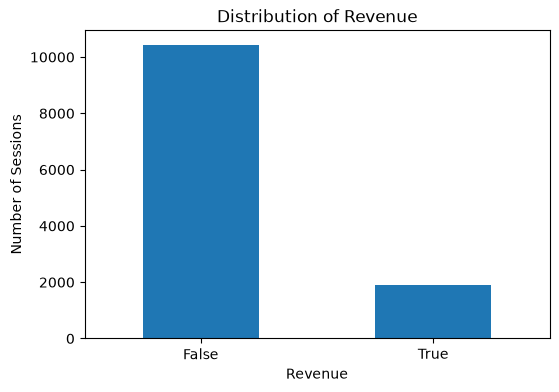

In [60]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
revenue_counts.plot(kind="bar")

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)

plt.show()

### Observation

The target variable `Revenue` is clearly imbalanced.

- `Revenue = False` (No Purchase): **10,422 sessions**, approximately **84.53%** of the dataset.
- `Revenue = True` (Purchase): **1,908 sessions**, approximately **15.47%** of the dataset.

This means that for every purchase session, there are roughly **5.5 non-purchase sessions**.

### Implication

Because the majority class (`Revenue = False`) is much larger than the minority class (`Revenue = True`), accuracy alone may give a misleading view of model performance. A model could achieve high accuracy by predicting mostly non-purchases while failing to identify actual purchasers.

Therefore, later model evaluation should also consider **Precision, Recall, F1-score, ROC-AUC, PR-AUC, and the Confusion Matrix**.

A **stratified train-test split** should also be used so that the proportion of purchase and non-purchase sessions is preserved in both the training and testing datasets.

## 2. Numerical Feature Distributions

In [107]:
df[numeric_features].describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


In [61]:
df[numeric_features].skew().sort_values(ascending=False)

Informational_Duration     7.579185
ProductRelated_Duration    7.263228
PageValues                 6.382964
Administrative_Duration    5.615719
ProductRelated             4.341516
Informational              4.036464
SpecialDay                 3.302667
BounceRates                2.947855
ExitRates                  2.148789
Administrative             1.960357
dtype: float64

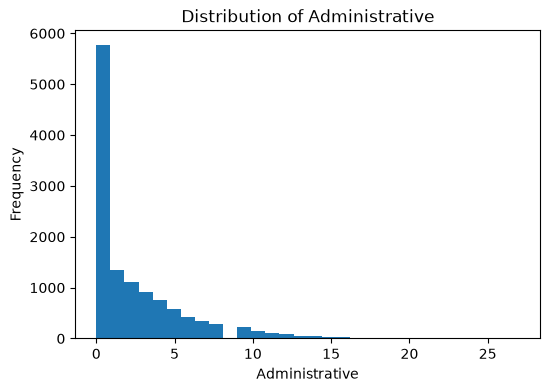

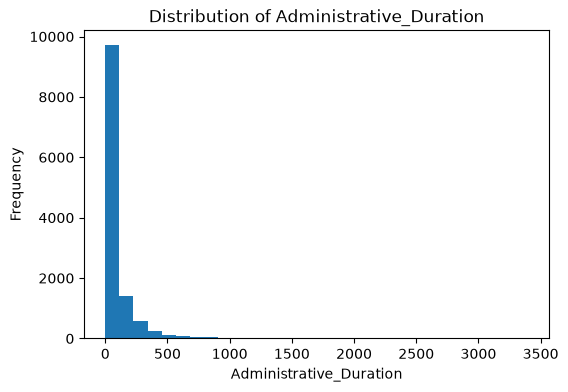

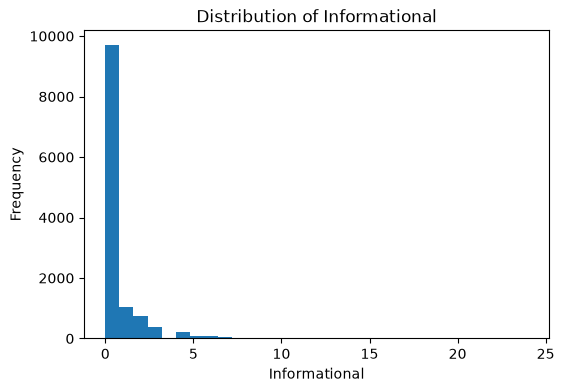

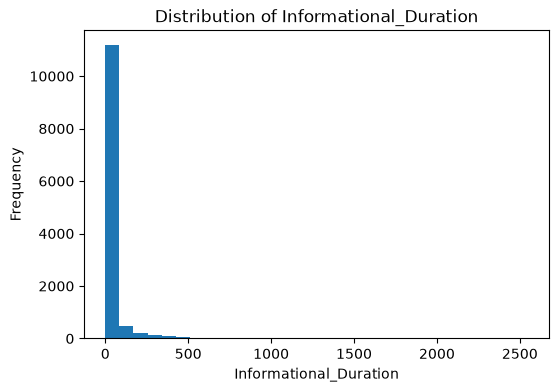

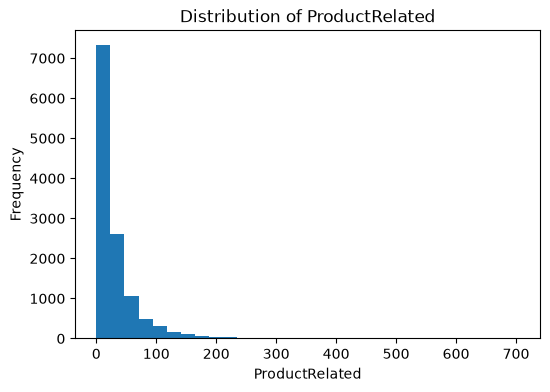

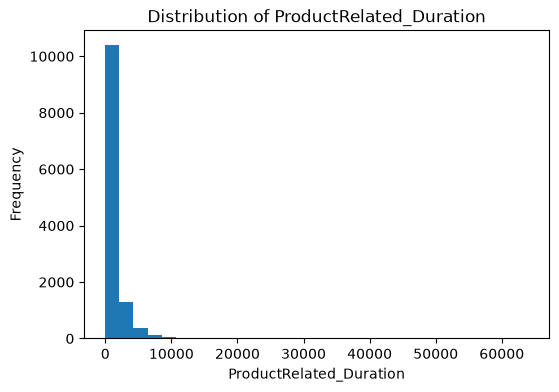

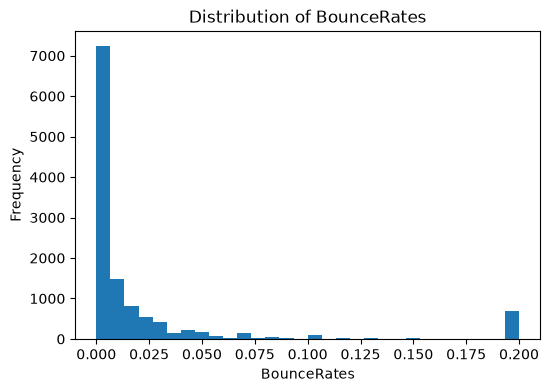

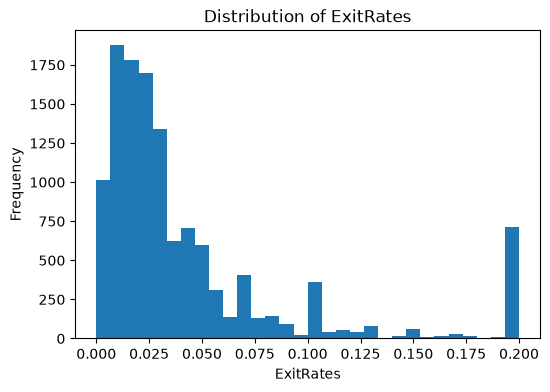

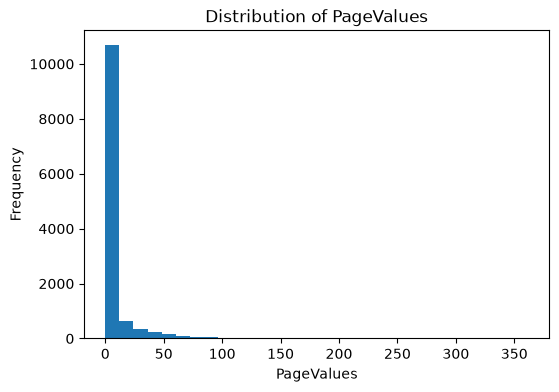

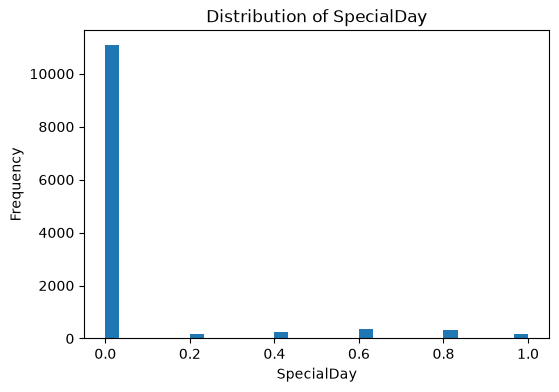

In [62]:
for col in numeric_features:
    plt.figure(figsize=(6, 4))

    plt.hist(
        df[col],
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

### Observations from Numerical Feature Distributions

The numerical variables show clear non-normal and highly skewed behaviour.

- **Administrative** is strongly right-skewed. Most sessions contain only a small number of administrative page visits, while a small number of sessions contain much higher values.

- **Administrative_Duration** is also highly right-skewed. Most users spend very little time on administrative pages, while a small number of sessions have very long durations.

- **Informational** is strongly concentrated around low values, especially zero or very few informational page visits. Only a small number of sessions contain high informational activity.

- **Informational_Duration** is extremely right-skewed. Most sessions record little or no time spent on informational pages, while a few sessions have very large durations.

- **ProductRelated** shows a wider range than the administrative and informational page-count variables. Most sessions still contain relatively few product-related page visits, but some users browse a very large number of product pages.

- **ProductRelated_Duration** is highly right-skewed with a very long right tail. Most users spend comparatively less time browsing product pages, while a small number of sessions have exceptionally long product-browsing durations.

- **BounceRates** is heavily concentrated near zero, meaning many sessions have low bounce rates. However, there is also a noticeable concentration around the upper value of approximately 0.20.

- **ExitRates** is also positively skewed. Most sessions have relatively low exit rates, but there are observations spread across higher values, including a visible concentration close to 0.20.

- **PageValues** is extremely right-skewed and contains a large concentration of values close to zero. A relatively small number of sessions have much higher PageValues, extending above 300.

- **SpecialDay** is highly concentrated at 0. Most sessions are therefore not closely associated with a special shopping day, while only a small proportion have values such as 0.2, 0.4, 0.6, 0.8 or 1.0.

### Overall Interpretation

Most behavioural variables are strongly right-skewed rather than normally distributed. This indicates that typical online shopping sessions have relatively low levels of activity, while a much smaller number of visitors display very high engagement.

The duration and page-count variables also contain long right tails, which suggests the presence of possible statistical outliers. However, these observations should not be removed automatically because they may represent genuine high-engagement browsing sessions.

### Implications for Preprocessing and Modelling

- The highly skewed numerical variables should be investigated further using box plots, percentiles and IQR-based outlier analysis.
- Log transformations such as `log1p()` may later be tested for strongly skewed non-negative variables, particularly for algorithms that are sensitive to feature distributions or scale.
- Statistical outliers should be investigated before deciding whether they require treatment.
- Scaling may be required later for algorithms such as Logistic Regression and K-Nearest Neighbours.
- Tree-based algorithms such as Decision Trees and Random Forests are generally less sensitive to skewness and feature scaling.
- `PageValues` should be investigated separately because its strong concentration near zero and high values may make it an influential predictor, and its availability at prediction time must be checked for possible data leakage.

## 3. Outlier Investigation

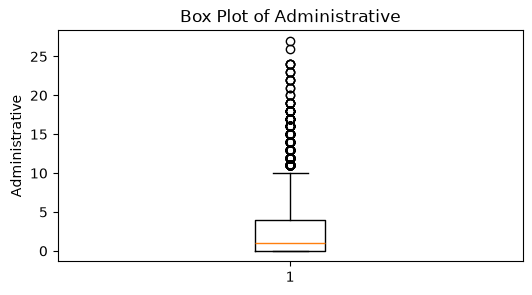

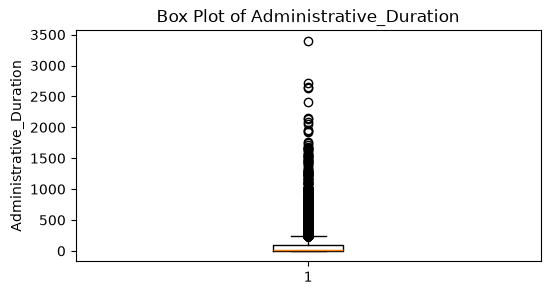

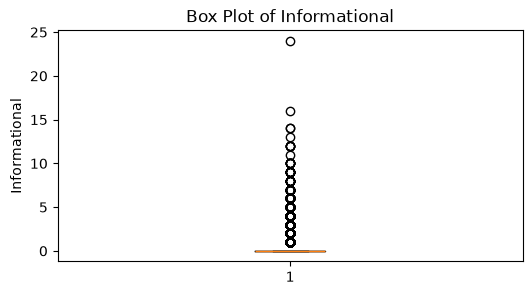

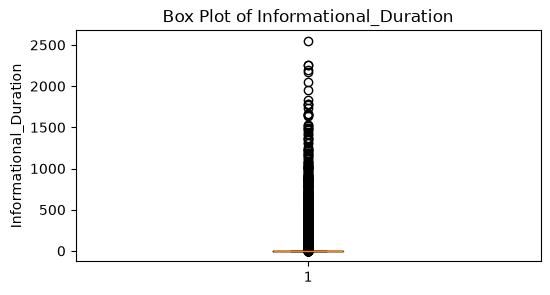

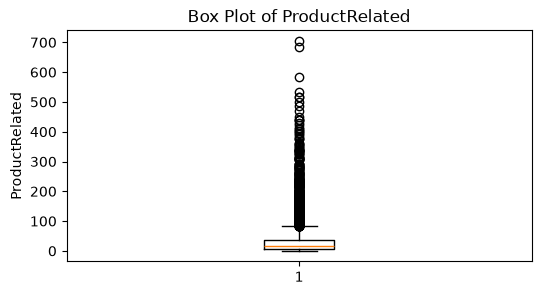

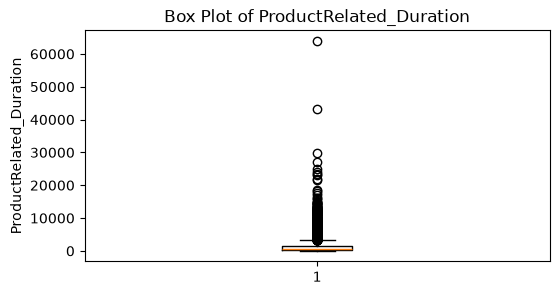

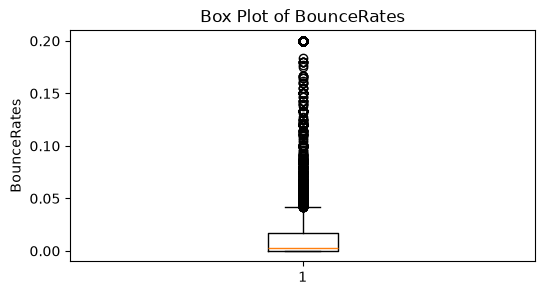

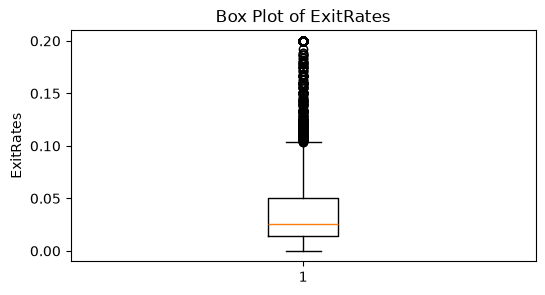

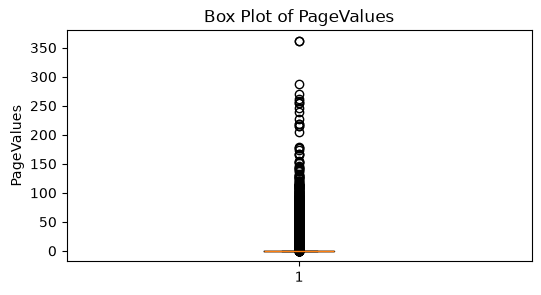

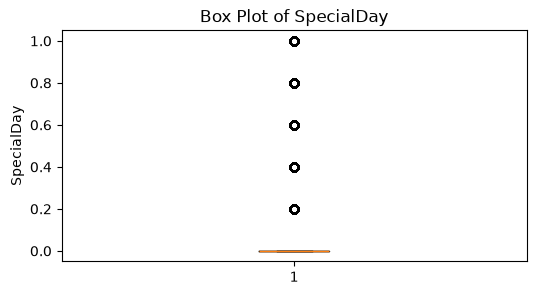

In [63]:
for col in numeric_features:
    plt.figure(figsize=(6, 3))

    plt.boxplot(df[col])

    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)

    plt.show()

### Observations from Box Plots

The box plots confirm that several numerical variables contain a large number of statistical outliers and are strongly right-skewed.

- **Administrative** shows many upper outliers above the main range of the data. Most sessions have only a few administrative page visits, while a smaller number contain substantially higher values.

- **Administrative_Duration** contains many high-value outliers, including a few very extreme observations. This confirms that most users spend relatively little time on administrative pages, while a small number of sessions last much longer.

- **Informational** is highly concentrated at very low values, with many observations identified as upper outliers. This indicates that most sessions involve little or no informational-page activity.

- **Informational_Duration** also shows a very large number of upper outliers. The majority of sessions have very low informational duration, while a few sessions have much longer durations.

- **ProductRelated** contains a wider spread than the administrative and informational page-count variables and has many high-value outliers. Some users therefore browse a very large number of product-related pages compared with the typical session.

- **ProductRelated_Duration** has several extreme upper outliers, including very large duration values. These may represent unusually long but potentially valid shopping sessions.

- **BounceRates** contains many upper outliers, with values extending close to 0.20. The majority of observations are concentrated at lower bounce-rate levels.

- **ExitRates** also contains many upper outliers. However, compared with BounceRates, the central spread is wider, indicating more variation in exit behaviour across sessions.

- **PageValues** is highly concentrated near zero, with many large upper outliers. A small number of sessions have exceptionally high PageValues, making this feature highly skewed.

- **SpecialDay** is concentrated at 0, while values such as 0.2, 0.4, 0.6, 0.8, and 1.0 appear as statistical outliers because most sessions are not close to a special shopping day. These values are valid by definition and should not be treated as data errors.

### Overall Interpretation

The box plots confirm that the dataset contains many statistical outliers, especially in page counts, duration variables, BounceRates, ExitRates, and PageValues.

However, these outliers should **not be removed automatically**. In this dataset, extreme observations may represent legitimate customer behaviour, such as users who spend an unusually long time browsing or visit a very large number of product pages.

Therefore, further investigation is required before deciding whether any outlier treatment is necessary.

### Implications for Preprocessing

- Outliers should be quantified using the IQR method and inspected before treatment.
- Clearly invalid values, if any, should be handled separately from valid extreme behaviour.
- Strongly skewed non-negative variables may later be tested using transformations such as `log1p()`.
- Scaling may be required for models such as Logistic Regression and K-Nearest Neighbours.
- Tree-based models are generally less sensitive to extreme scale differences and skewness.
- `SpecialDay` values should be retained because its discrete values are valid and the apparent outliers are caused by the heavy concentration at zero rather than by erroneous data.
- `PageValues` requires separate leakage and prediction-time availability analysis before final modelling.

In [64]:
def count_iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return len(outliers)

In [65]:
outlier_summary = {}

for col in numeric_features:
    outlier_summary[col] = count_iqr_outliers(df, col)

pd.Series(outlier_summary).sort_values(ascending=False)

PageValues                 2730
Informational              2631
Informational_Duration     2405
BounceRates                1551
SpecialDay                 1251
Administrative_Duration    1172
ExitRates                  1099
ProductRelated              987
ProductRelated_Duration     961
Administrative              404
dtype: int64

## 4. Categorical Feature Analysis

In [66]:
for col in categorical_features:
    print("\nCOLUMN:", col)
    print(df[col].value_counts())


COLUMN: Month
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

COLUMN: OperatingSystems
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64

COLUMN: Browser
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64

COLUMN: Region
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64

COLUMN: TrafficType
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

COLUMN: VisitorType
VisitorType
Returning_Visitor    10551
Ne

In [67]:
for col in categorical_features:
    print("\nCOLUMN:", col)
    print(df[col].value_counts(normalize=True) * 100)


COLUMN: Month
Month
May     27.283049
Nov     24.314680
Mar     15.466342
Dec     14.006488
Oct      4.452555
Sep      3.633414
Aug      3.511760
Jul      3.503650
June     2.335766
Feb      1.492295
Name: proportion, dtype: float64

COLUMN: OperatingSystems
OperatingSystems
2    53.536091
1    20.965126
3    20.721817
4     3.876723
8     0.640714
6     0.154096
7     0.056772
5     0.048662
Name: proportion, dtype: float64

COLUMN: Browser
Browser
2     64.566099
1     19.967559
4      5.969181
5      3.787510
6      1.411192
10     1.321979
8      1.094891
3      0.851582
13     0.494728
7      0.397405
12     0.081103
11     0.048662
9      0.008110
Name: proportion, dtype: float64

COLUMN: Region
Region
1    38.767234
3    19.489051
4     9.586375
2     9.213301
6     6.528792
7     6.171938
9     4.144363
8     3.519870
5     2.579075
Name: proportion, dtype: float64

COLUMN: TrafficType
TrafficType
2     31.735604
1     19.878345
3     16.642336
4      8.669911
13     5.985401


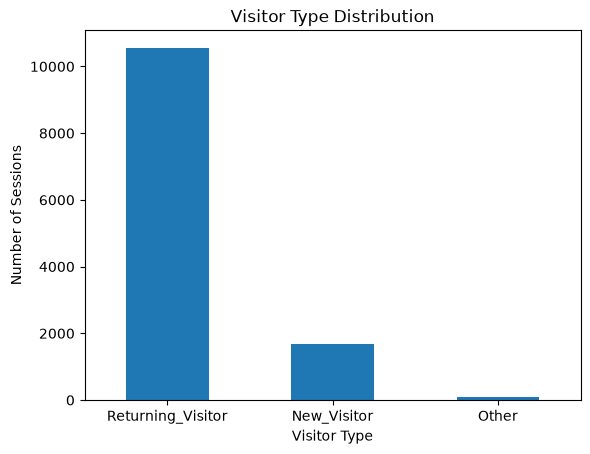

In [68]:
df["VisitorType"].value_counts().plot(kind="bar")

plt.title("Visitor Type Distribution")
plt.xlabel("Visitor Type")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)

plt.show()

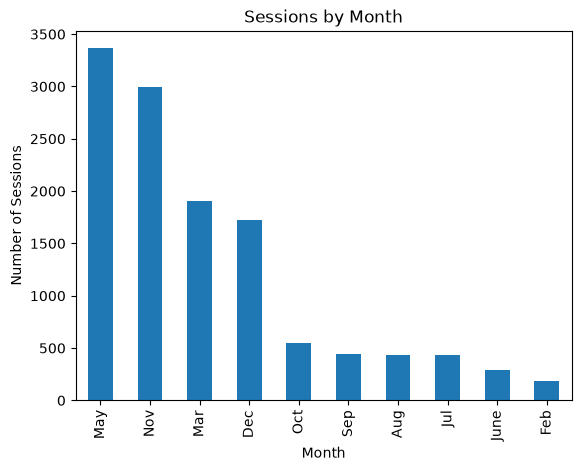

In [69]:
df["Month"].value_counts().plot(kind="bar")

plt.title("Sessions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")

plt.show()

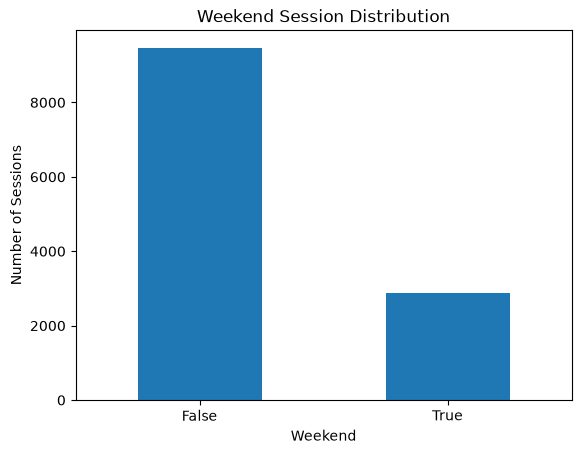

In [70]:
df["Weekend"].value_counts().plot(kind="bar")

plt.title("Weekend Session Distribution")
plt.xlabel("Weekend")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)

plt.show()

## 5. Relationship Between Features and Revenue

In [71]:
visitor_purchase_rate = (
    df.groupby("VisitorType")["Revenue"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

visitor_purchase_rate

VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64

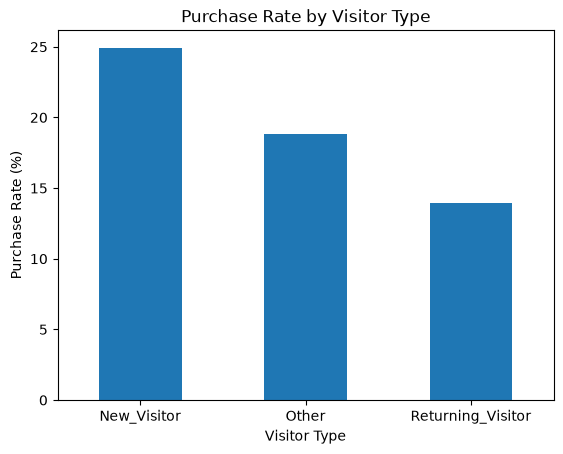

In [72]:
visitor_purchase_rate.plot(kind="bar")

plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [73]:
monthly_purchase_rate = (
    df.groupby("Month")["Revenue"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

monthly_purchase_rate

Month
Nov     25.350233
Oct     20.947177
Sep     19.196429
Aug     17.551963
Jul     15.277778
Dec     12.507238
May     10.850178
June    10.069444
Mar     10.068170
Feb      1.630435
Name: Revenue, dtype: float64

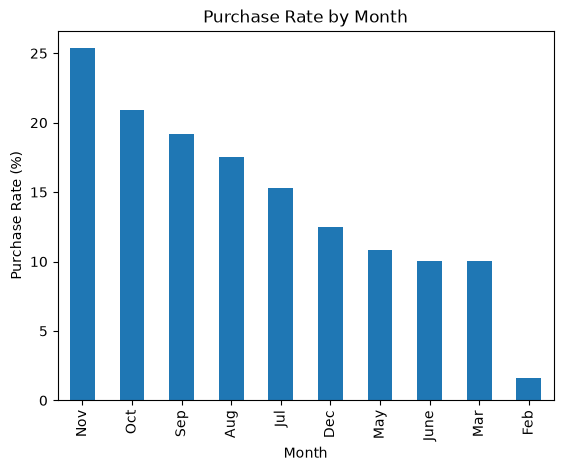

In [74]:
monthly_purchase_rate.plot(kind="bar")

plt.title("Purchase Rate by Month")
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")

plt.show()

In [75]:
weekend_purchase_rate = (
    df.groupby("Weekend")["Revenue"]
      .mean()
      * 100
)

weekend_purchase_rate

Weekend
False    14.891144
True     17.398884
Name: Revenue, dtype: float64

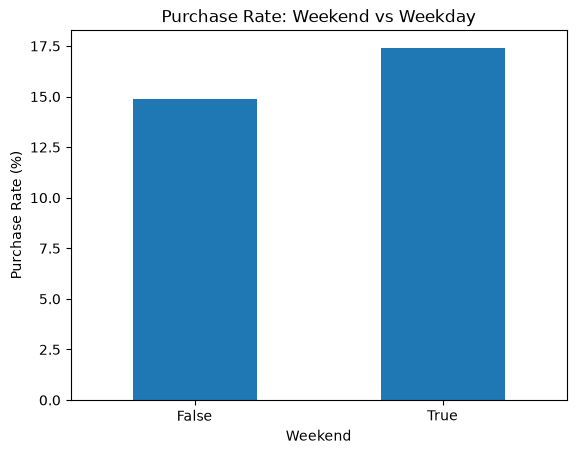

In [76]:
weekend_purchase_rate.plot(kind="bar")

plt.title("Purchase Rate: Weekend vs Weekday")
plt.xlabel("Weekend")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [77]:
df.groupby("Revenue")["ProductRelated"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,28.714642,40.744717,0.0,6.0,16.0,35.0,705.0
True,1908.0,48.210168,58.267365,0.0,15.0,29.0,57.0,534.0


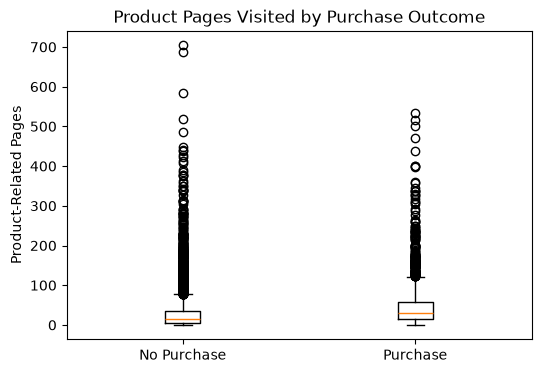

In [78]:
purchase = df[df["Revenue"] == True]["ProductRelated"]
no_purchase = df[df["Revenue"] == False]["ProductRelated"]

plt.figure(figsize=(6, 4))

plt.boxplot(
    [no_purchase, purchase],
    tick_labels=["No Purchase", "Purchase"]
)

plt.title("Product Pages Visited by Purchase Outcome")
plt.ylabel("Product-Related Pages")

plt.show()

In [79]:
df.groupby("Revenue")["ProductRelated_Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1069.987809,1803.797757,0.0,151.00000,510.19000,1331.816667,63973.52223
True,1908.0,1876.209615,2312.214392,0.0,541.90625,1109.90625,2266.011310,27009.85943


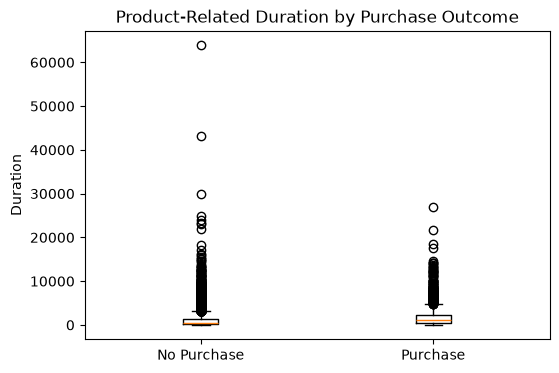

In [81]:
purchase = df[df["Revenue"] == True]["ProductRelated_Duration"]
no_purchase = df[df["Revenue"] == False]["ProductRelated_Duration"]

plt.figure(figsize=(6, 4))

plt.boxplot(
    [no_purchase, purchase],
    tick_labels=["No Purchase", "Purchase"]
)

plt.title("Product-Related Duration by Purchase Outcome")
plt.ylabel("Duration")

plt.show()

In [82]:
df.groupby("Revenue")["BounceRates"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.025317,0.051877,0.0,0.0,0.004255,0.020000,0.2
True,1908.0,0.005117,0.012185,0.0,0.0,0.000000,0.006452,0.2


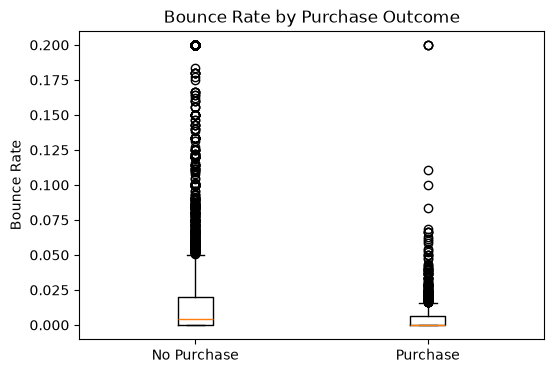

In [83]:
purchase = df[df["Revenue"] == True]["BounceRates"]
no_purchase = df[df["Revenue"] == False]["BounceRates"]

plt.figure(figsize=(6, 4))

plt.boxplot(
    [no_purchase, purchase],
    tick_labels=["No Purchase", "Purchase"]
)

plt.title("Bounce Rate by Purchase Outcome")
plt.ylabel("Bounce Rate")

plt.show()

In [84]:
df.groupby("Revenue")["ExitRates"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,0.047378,0.051231,0.0,0.015560,0.028571,0.053846,0.2
True,1908.0,0.019555,0.016463,0.0,0.009521,0.016000,0.025000,0.2


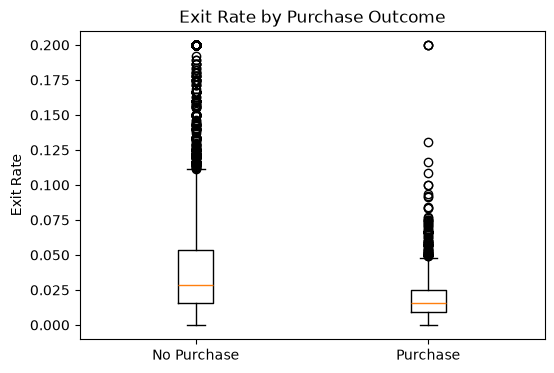

In [85]:
purchase = df[df["Revenue"] == True]["ExitRates"]
no_purchase = df[df["Revenue"] == False]["ExitRates"]

plt.figure(figsize=(6, 4))

plt.boxplot(
    [no_purchase, purchase],
    tick_labels=["No Purchase", "Purchase"]
)

plt.title("Exit Rate by Purchase Outcome")
plt.ylabel("Exit Rate")

plt.show()

In [86]:
df.groupby("Revenue")["PageValues"].describe()

,count,mean,std,min,25%,50%,75%,max
Revenue,,,,,,,,
False,10422.0,1.975998,9.072424,0.0,0.000000,0.000000,0.000000,246.758590
True,1908.0,27.264518,35.191954,0.0,3.641144,16.758134,38.897742,361.763742


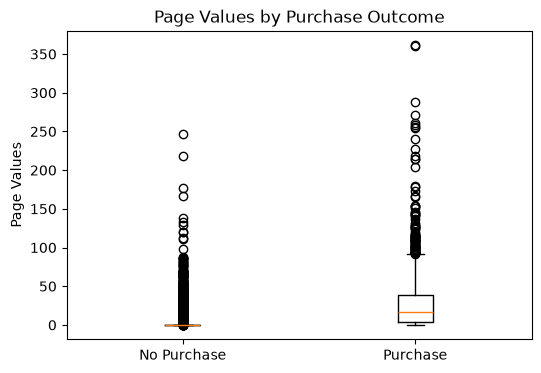

In [87]:
purchase = df[df["Revenue"] == True]["PageValues"]
no_purchase = df[df["Revenue"] == False]["PageValues"]

plt.figure(figsize=(6, 4))

plt.boxplot(
    [no_purchase, purchase],
    tick_labels=["No Purchase", "Purchase"]
)

plt.title("Page Values by Purchase Outcome")
plt.ylabel("Page Values")

plt.show()

### Observation

`PageValues` is much higher for purchase sessions than for non-purchase sessions.

- **No Purchase:** median = **0.00**, mean = **1.98**
- **Purchase:** median = **16.76**, mean = **27.26**

This indicates that `PageValues` has a strong relationship with `Revenue`.

### Leakage Consideration

Because `PageValues` is strongly associated with the purchase outcome, we must confirm that it would be available at the time the prediction is made. To avoid potential data leakage, later models should be compared **with and without `PageValues`**.

In [88]:
specialday_purchase_rate = (
    df.groupby("SpecialDay")["Revenue"]
      .mean()
      * 100
)

specialday_purchase_rate

SpecialDay
0.0    16.526762
0.2     7.865169
0.4     5.349794
0.6     8.262108
0.8     3.384615
1.0     6.493506
Name: Revenue, dtype: float64

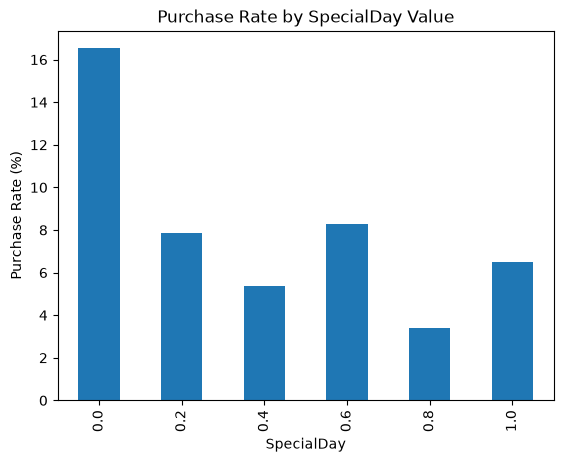

In [89]:
specialday_purchase_rate.plot(kind="bar")

plt.title("Purchase Rate by SpecialDay Value")
plt.xlabel("SpecialDay")
plt.ylabel("Purchase Rate (%)")

plt.show()

In [90]:
traffic_purchase_rate = (
    df.groupby("TrafficType")["Revenue"]
      .agg(["mean", "count"])
)

traffic_purchase_rate["purchase_rate_percent"] = (
    traffic_purchase_rate["mean"] * 100
)

traffic_purchase_rate.sort_values(
    "purchase_rate_percent",
    ascending=False
)

,mean,count,purchase_rate_percent
TrafficType,,,
16,0.333333,3,33.333333
7,0.300000,40,30.000000
8,0.276968,343,27.696793
20,0.252525,198,25.252525
2,0.216458,3913,21.645796
5,0.215385,260,21.538462
10,0.200000,450,20.000000
11,0.190283,247,19.028340
4,0.154350,1069,15.434986


In [91]:
browser_purchase_rate = (
    df.groupby("Browser")["Revenue"]
      .agg(["mean", "count"])
)

browser_purchase_rate["purchase_rate_percent"] = (
    browser_purchase_rate["mean"] * 100
)

browser_purchase_rate.sort_values(
    "purchase_rate_percent",
    ascending=False
)

,mean,count,purchase_rate_percent
Browser,,,
12,0.300000,10,30.000000
13,0.262295,61,26.229508
10,0.196319,163,19.631902
5,0.184154,467,18.415418
4,0.176630,736,17.663043
11,0.166667,6,16.666667
8,0.155556,135,15.555556
2,0.153624,7961,15.362392
1,0.148253,2462,14.825345


In [92]:
region_purchase_rate = (
    df.groupby("Region")["Revenue"]
      .agg(["mean", "count"])
)

region_purchase_rate["purchase_rate_percent"] = (
    region_purchase_rate["mean"] * 100
)

region_purchase_rate.sort_values(
    "purchase_rate_percent",
    ascending=False
)

,mean,count,purchase_rate_percent
Region,,,
9,0.168297,511,16.829746
2,0.165493,1136,16.549296
5,0.163522,318,16.352201
1,0.161297,4780,16.129707
7,0.156373,761,15.637319
4,0.148054,1182,14.805415
3,0.145235,2403,14.523512
6,0.139130,805,13.913043
8,0.129032,434,12.903226


## 6. Correlation Analysis

In [93]:
corr = df[numeric_features].corr()

In [94]:
corr

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
Administrative,1.000000,0.601583,0.376850,0.255848,0.431119,0.373939,-0.223563,-0.316483,0.098990,-0.094778
Administrative_Duration,0.601583,1.000000,0.302710,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608,-0.073304
Informational,0.376850,0.302710,1.000000,0.618955,0.374164,0.387505,-0.116114,-0.163666,0.048632,-0.048219
Informational_Duration,0.255848,0.238031,0.618955,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861,-0.030577
ProductRelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958
ProductRelated_Duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380
BounceRates,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702
ExitRates,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242
PageValues,0.098990,0.067608,0.048632,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000,-0.063541
SpecialDay,-0.094778,-0.073304,-0.048219,-0.030577,-0.023958,-0.036380,0.072702,0.102242,-0.063541,1.000000


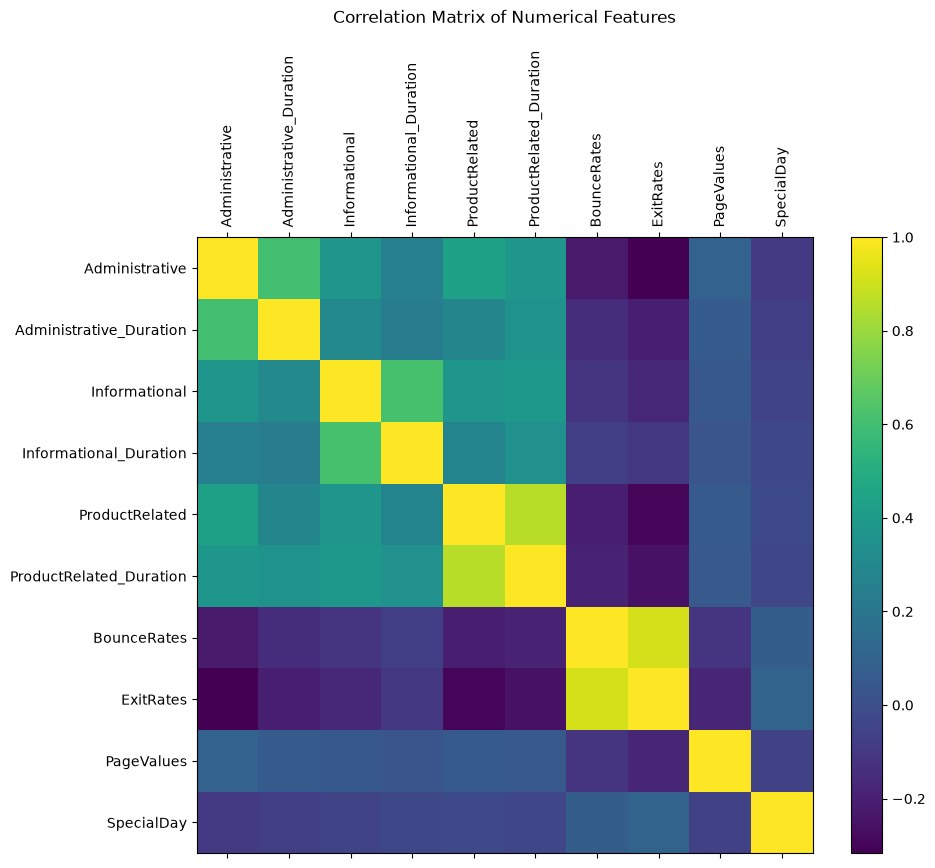

In [95]:
fig, ax = plt.subplots(figsize=(10, 8))

cax = ax.matshow(corr)

fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix of Numerical Features", pad=20)

plt.show()

In [96]:
corr_pairs = (
    corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=abs,
        ascending=False
    )
)

corr_pairs.head(10)

BounceRates              ExitRates                  0.913004
ProductRelated           ProductRelated_Duration    0.860927
Informational            Informational_Duration     0.618955
Administrative           Administrative_Duration    0.601583
                         ProductRelated             0.431119
Informational            ProductRelated_Duration    0.387505
Administrative           Informational              0.376850
Informational            ProductRelated             0.374164
Administrative           ProductRelated_Duration    0.373939
Administrative_Duration  ProductRelated_Duration    0.355422
dtype: float64

In [97]:
revenue_numeric_summary = (
    df.groupby("Revenue")[numeric_features]
      .mean()
      .T
)

revenue_numeric_summary

Revenue,False,True
Administrative,2.117732,3.393606
Administrative_Duration,73.740111,119.483244
Informational,0.451833,0.786164
Informational_Duration,30.236237,57.611427
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518
SpecialDay,0.068432,0.023166


In [98]:
revenue_numeric_median = (
    df.groupby("Revenue")[numeric_features]
      .median()
      .T
)

revenue_numeric_median

Revenue,False,True
Administrative,0.000000,2.000000
Administrative_Duration,0.000000,52.366667
Informational,0.000000,0.000000
Informational_Duration,0.000000,0.000000
ProductRelated,16.000000,29.000000
ProductRelated_Duration,510.190000,1109.906250
BounceRates,0.004255,0.000000
ExitRates,0.028571,0.016000
PageValues,0.000000,16.758134
SpecialDay,0.000000,0.000000


In [99]:
duplicates = df[df.duplicated(keep=False)]

print("Duplicate group rows:", len(duplicates))

print(
    duplicates["Revenue"].value_counts()
)

Duplicate group rows: 201
Revenue
False    201
Name: count, dtype: int64


### Duplicate Analysis

201 records belong to exact duplicate groups, and all of these duplicated observations are from the non-purchase class.

However, identical browsing behaviour does not necessarily indicate erroneous duplication because different users may produce the same recorded session characteristics.

Therefore, duplicate rows will not be removed automatically. A later sensitivity analysis can compare modelling results with and without exact duplicates.

## 7. Validity Checks

In [100]:
for col in numeric_features:
    negative_count = (df[col] < 0).sum()

    print(
        col,
        ":",
        negative_count
    )

Administrative : 0
Administrative_Duration : 0
Informational : 0
Informational_Duration : 0
ProductRelated : 0
ProductRelated_Duration : 0
BounceRates : 0
ExitRates : 0
PageValues : 0
SpecialDay : 0


In [101]:
df["Weekend"].unique()

array([False,  True])

In [102]:
df["Revenue"].unique()

array([False,  True])

In [103]:
for col in categorical_features:
    print(
        col,
        df[col].unique()
    )

Month <StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str
OperatingSystems [1 2 4 3 7 6 8 5]
Browser [ 1  2  3  4  5  6  7 10  8  9 12 13 11]
Region [1 9 2 3 4 5 6 7 8]
TrafficType [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]
VisitorType <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str


In [104]:
pd.set_option("display.max_colwidth", None)

In [105]:
eda_findings = pd.DataFrame({
    "Finding": [
        "Revenue is imbalanced",
        "Most numerical variables are strongly right-skewed",
        "Many statistical outliers are present",
        "PageValues is strongly related to purchase outcome",
        "Exact duplicate records exist",
        "No negative values were found in numerical features",
        "Boolean variables are valid",
        "Some categorical variables are highly concentrated",
        "Session activity varies considerably across categories",
        "Category codes are stored as integers"
    ],

    "Evidence from EDA": [
        "10,422 sessions (84.53%) are non-purchases and 1,908 (15.47%) are purchases.",
        "Page counts, duration variables, BounceRates, ExitRates and PageValues show long right tails.",
        "Box plots show many upper outliers, especially in duration, page-count and PageValues variables.",
        "Median PageValues is 0.00 for non-purchases and 16.76 for purchases; mean values are 1.98 and 27.26 respectively.",
        "201 rows belong to duplicate groups, and all of them are from the non-purchase class.",
        "All checked numerical columns returned 0 negative values.",
        "Weekend and Revenue contain only True and False.",
        "Returning visitors represent about 85.57% of sessions; Browser 2 about 64.57%; Operating System 2 about 53.54%.",
        "May and November contain the largest shares of sessions, while some Browser and TrafficType categories are very rare.",
        "OperatingSystems, Browser, Region and TrafficType appear numeric but represent categories."
    ],

    "Implication / Planned Action": [
        "Use stratified train-test splitting and evaluate models using Precision, Recall, F1-score, ROC-AUC/PR-AUC in addition to Accuracy.",
        "Investigate transformations such as log1p() for suitable models rather than assuming normal distributions.",
        "Do not remove them automatically because they may represent valid high-engagement browsing sessions. Investigate before treatment.",
        "Treat PageValues as an important predictor, but check whether it is available at prediction time. Compare models with and without it to assess possible leakage.",
        "Retain them initially because identical browsing behaviour may represent separate real sessions. A later sensitivity test can compare results with and without duplicates.",
        "No correction for invalid negative values is required.",
        "No cleaning is required for these variables.",
        "Category imbalance should be considered during encoding and interpretation.",
        "Rare categories should be monitored during preprocessing, and categorical variables should be encoded appropriately.",
        "Treat them as categorical variables and use appropriate encoding rather than treating the numbers as continuous values."
    ]
})

eda_findings

,Finding,Evidence from EDA,Implication / Planned Action
0,Revenue is imbalanced,"10,422 sessions (84.53%) are non-purchases and 1,908 (15.47%) are purchases.","Use stratified train-test splitting and evaluate models using Precision, Recall, F1-score, ROC-AUC/PR-AUC in addition to Accuracy."
1,Most numerical variables are strongly right-skewed,"Page counts, duration variables, BounceRates, ExitRates and PageValues show long right tails.",Investigate transformations such as log1p() for suitable models rather than assuming normal distributions.
2,Many statistical outliers are present,"Box plots show many upper outliers, especially in duration, page-count and PageValues variables.",Do not remove them automatically because they may represent valid high-engagement browsing sessions. Investigate before treatment.
3,PageValues is strongly related to purchase outcome,Median PageValues is 0.00 for non-purchases and 16.76 for purchases; mean values are 1.98 and 27.26 respectively.,"Treat PageValues as an important predictor, but check whether it is available at prediction time. Compare models with and without it to assess possible leakage."
4,Exact duplicate records exist,"201 rows belong to duplicate groups, and all of them are from the non-purchase class.",Retain them initially because identical browsing behaviour may represent separate real sessions. A later sensitivity test can compare results with and without duplicates.
5,No negative values were found in numerical features,All checked numerical columns returned 0 negative values.,No correction for invalid negative values is required.
6,Boolean variables are valid,Weekend and Revenue contain only True and False.,No cleaning is required for these variables.
7,Some categorical variables are highly concentrated,Returning visitors represent about 85.57% of sessions; Browser 2 about 64.57%; Operating System 2 about 53.54%.,Category imbalance should be considered during encoding and interpretation.
8,Session activity varies considerably across categories,"May and November contain the largest shares of sessions, while some Browser and TrafficType categories are very rare.","Rare categories should be monitored during preprocessing, and categorical variables should be encoded appropriately."
9,Category codes are stored as integers,"OperatingSystems, Browser, Region and TrafficType appear numeric but represent categories.",Treat them as categorical variables and use appropriate encoding rather than treating the numbers as continuous values.


## Final EDA Conclusion

The exploratory data analysis identified several important characteristics of the Online Shoppers Purchasing Intention Dataset.

The target variable `Revenue` is clearly imbalanced, with purchase sessions representing only 15.47% of the dataset. Therefore, stratified splitting and evaluation metrics beyond accuracy will be required during modelling.

Most numerical variables are strongly right-skewed and contain many statistical outliers. However, these extreme values may represent genuine customer browsing behaviour, so they should not be removed automatically. Appropriate transformations or scaling will be considered only where justified by the selected algorithms.

`PageValues` shows a particularly strong relationship with the purchase outcome, with much higher values among purchase sessions. Because of this strong relationship, its availability at prediction time must be checked carefully to avoid possible data leakage.

The dataset also contains 201 rows belonging to exact duplicate groups, all from the non-purchase class. Since identical session characteristics may occur naturally, these records will be retained initially and their effect can later be tested through sensitivity analysis.

No negative values were identified in the numerical variables, and the Boolean and categorical variables contain valid values. Several categorical variables are unevenly distributed, and category-coded integer variables such as Browser, Region, OperatingSystems and TrafficType will be treated as categorical during preprocessing.

Overall, the EDA shows that the dataset is suitable for further preprocessing and modelling, but class imbalance, skewness, outliers, categorical encoding, duplicate handling and possible leakage from `PageValues` must be handled carefully in the next stage.